In [1]:
import sys
sys.path.insert(0, '../')
import torch.nn as nn
import torch
import pandas as pd
import numpy as np
import os
from src.load_dataset import load_dataset, select_normalizer
from src.config import models_features_per
from src.utils import per_error, evaluate_score_class_stratified
from src.graph_visualization import visualization_class_stratified
from src.load_models import select_model

import wandb

In [2]:
class VoltNeural(nn.Module):
    def __init__(self,
                input_dim,
                hidden_dim,
                output,
                device):
        
        super(VoltNeural, self).__init__()
        self.input_layer    = nn.Linear(input_dim,    hidden_dim,     device=device)
        self.hidden_layer1  = nn.Linear(hidden_dim,   hidden_dim*2,   device=device)
        self.hidden_layer2  = nn.Linear(hidden_dim*2, hidden_dim*2,   device=device)
        self.hidden_layer3  = nn.Linear(hidden_dim*2, hidden_dim,     device=device)
        self.hidden_layer4  = nn.Linear(hidden_dim,   hidden_dim//2,  device=device)
        self.output_layer   = nn.Linear(hidden_dim//2,            1,  device=device)
    
        self.relu          = nn.ReLU()
        self.sigmoid       = nn.Sigmoid()

    def forward(self, x):
        x = self.input_layer(x)
        x = self.relu(x)
        x = self.hidden_layer1(x)
        x = self.relu(x)
        x = self.hidden_layer2(x)
        x = self.relu(x)
        x = self.hidden_layer3(x)
        x = self.relu(x)
        x = self.hidden_layer4(x)
        x = self.relu(x)
        x = self.output_layer(x)
        x = self.relu(x)

        return x

In [3]:
def normalize_create_training_data(train, test, blank_norm=False, remove_outlier=None, normalizer_type='mean_std'):

    # Remove outlier only from the training dataset
    if remove_outlier=='all':
        
        train = train[train['file'].apply(lambda x: False if (x.split('/')[-1].replace('.txt', '') in ouliners_to_remove) else True)]
        test  = test[test['file'].apply(lambda x: False if (x.split('/')[-1].replace('.txt', '') in ouliners_to_remove) else True)]

    elif remove_outlier=='train_only':
        train = train[train['file'].apply(lambda x: False if (x.split('/')[-1].replace('.txt', '') in ouliners_to_remove) else True)]
        
    train = train.reset_index(drop=True)
    test  = test.reset_index(drop=True)
    
    X_train = train.drop(columns=['file']).copy()
    X_test  = test.drop(columns=['file']).copy()

    columns       = X_train.columns
    
    y_train = train['file'].apply(lambda x: int(x.split('_')[-2].replace('cbz','')))
    y_test  = test['file'].apply(lambda x: int(x.split('_')[-2].replace('cbz','')))

    assert (X_train.index.values == y_train.index.values).all()

    if normalizer_type!=None:
        scaler  = select_normalizer(normalizer_type)
    
        if blank_norm: scaler.fit(X_train[y_train==0])
        else: scaler.fit(X_train)
    
        
        X_train = pd.DataFrame(scaler.transform(X_train), columns=columns)
        X_test  = pd.DataFrame(scaler.transform(X_test),  columns=columns)

    else:
        scaler = None

    X_train.rename(columns={"PH": 'univariate, max(S)', 'signal_std':'univariate, std(S)', 'signal_mean':'univariate, mean(S)', 'peak area':'univariate, area(S)', \
                        'dS_dV_area':'univariate, area(dS/dV)', 'dS_dV_max_peak':'univariate, max(dS/dV)', 'dS_dV_min_peak':'univariate, min(dS/dV)',\
                    'dS_dV_peak_diff':'univariate, max(dS/dV) - min(dS/dV)', \
                    'peak V':'univariate, V_max(S)', 'dS_dV_max_V':'univariate, V_max(dS/dV)', 'dS_dV_min_V':'univariate, V_min(dS/dV)',\
        }, inplace = True)

    X_test.rename(columns={"PH": 'univariate, max(S)', 'signal_std':'univariate, std(S)', 'signal_mean':'univariate, mean(S)', 'peak area':'univariate, area(S)', \
                        'dS_dV_area':'univariate, area(dS/dV)', 'dS_dV_max_peak':'univariate, max(dS/dV)', 'dS_dV_min_peak':'univariate, min(dS/dV)',\
                    'dS_dV_peak_diff':'univariate, max(dS/dV) - min(dS/dV)', \
                    'peak V':'univariate, V_max(S)', 'dS_dV_max_V':'univariate, V_max(dS/dV)', 'dS_dV_min_V':'univariate, V_min(dS/dV)',\
        }, inplace = True)

   

    return (X_train, X_test, y_train, y_test), scaler


def load_dataset_train_test_splitted(filename, load_dataset_name=['ML1', 'ML2', 'ML4']):
    dataset = {}

    if 'ML1' in load_dataset_name:
        dataset['ML1'] = pd.read_excel(f'../dataset/ML1_ML2/2024_02_19_ML1/{filename}.xlsx')

    if 'ML2' in load_dataset_name:
         dataset['ML2'] = pd.read_excel(f'../dataset/ML1_ML2/2024_02_22_ML2/{filename}.xlsx')
    
    if 'ML4' in load_dataset_name:
        dataset['ML4'] = pd.read_excel(f'../dataset/ML4/{filename}.xlsx')

    return dataset

In [4]:
# load dataset
# (ML1_X_train, ML1_X_test, ML1_y_train, ML1_y_test), _  = load_dataset('/Users/sangam/Desktop/Epilepsey/Code/vgramreg/dataset/ML1_ML2/2024_02_19_ML1', standardize_type='mean_std')
# (ML2_X_train, ML2_X_test, ML2_y_train, ML2_y_test), _  = load_dataset('/Users/sangam/Desktop/Epilepsey/Code/vgramreg/dataset/ML1_ML2/2024_02_22_ML2', standardize_type='mean_std')
# (ML4_X_train, ML4_X_test, ML4_y_train, ML4_y_test), _  = load_dataset('/Users/sangam/Desktop/Epilepsey/Code/vgramreg/dataset/ML4', standardize_type='mean_std')
vwidth      = 0.15
all_dataset = True
root_min    = True

ML1_noisy_train, ML2_noisy_train, ML4_noisy_train = list(load_dataset_train_test_splitted(f"feature_extraction_vwidth_{vwidth}_{'root_min_' if root_min else ''}training_noisy").values())
ML1_train, ML2_train, ML4_train = list(load_dataset_train_test_splitted(f"feature_extraction_vwidth_{vwidth}_{'root_min_' if root_min else ''}training").values())
ML1_test, ML2_test, ML4_test    = list(load_dataset_train_test_splitted(f"feature_extraction_vwidth_{vwidth}_{'root_min_' if root_min else ''}testing").values())


In [5]:
ouliners_to_remove = ['2024_02_19_cbz08_40',
                      '2024_02_19_cbz00_15',
                      '2024_02_19_cbz08_37',
                      '2024_02_22_cbz00_31',
                     '2024_02_22_cbz16_21',
                     '2024_02_22_cbz08_10',
                     '2024_02_22_cbz00_01',
                     '2024_02_22_cbz08_01']

In [6]:
data_propery    = 'augmentation' # noisy, augmentation, and noiseless
blank_norm      = False
remove_outlier  = 'train_only'   #None, train_only, all
normalizer_type = 'mean_std'
use_combat      = False
add_alpha       = False

if data_propery=='noisy':
    (ML1_X_train, ML1_X_test, ML1_y_train, ML1_y_test), ML1_scalar = normalize_create_training_data(ML1_noisy_train, ML1_test, blank_norm, remove_outlier, normalizer_type=normalizer_type)
    (ML2_X_train, ML2_X_test, ML2_y_train, ML2_y_test), ML2_scalar = normalize_create_training_data(ML2_noisy_train, ML2_test, blank_norm, remove_outlier, normalizer_type=normalizer_type)
    if all_dataset:
        (ML4_X_train, ML4_X_test, ML4_y_train, ML4_y_test), ML4_scalar = normalize_create_training_data(ML4_noisy_train, ML4_test, blank_norm, remove_outlier, normalizer_type=normalizer_type)

elif data_propery=='augmentation':
    ML1_train_combined = pd.concat([ML1_noisy_train, ML1_train])
    ML2_train_combined = pd.concat([ML2_noisy_train, ML2_train])

    if all_dataset:
        ML4_train_combined = pd.concat([ML4_noisy_train, ML4_train])
    
    (ML1_X_train, ML1_X_test, ML1_y_train, ML1_y_test), ML1_scalar = normalize_create_training_data(ML1_train_combined, ML1_test, blank_norm, remove_outlier, normalizer_type=normalizer_type)
    (ML2_X_train, ML2_X_test, ML2_y_train, ML2_y_test), ML2_scalar = normalize_create_training_data(ML2_train_combined, ML2_test, blank_norm, remove_outlier, normalizer_type=normalizer_type)
    if all_dataset:
        (ML4_X_train, ML4_X_test, ML4_y_train, ML4_y_test), ML4_scalar = normalize_create_training_data(ML4_train_combined, ML4_test, blank_norm, remove_outlier, normalizer_type=normalizer_type)
    
else:
    (ML1_X_train, ML1_X_test, ML1_y_train, ML1_y_test), ML1_scalar = normalize_create_training_data(ML1_train, ML1_test, blank_norm, remove_outlier, normalizer_type=normalizer_type)
    (ML2_X_train, ML2_X_test, ML2_y_train, ML2_y_test), ML2_scalar = normalize_create_training_data(ML2_train, ML2_test, blank_norm, remove_outlier, normalizer_type=normalizer_type)
    if all_dataset:
        (ML4_X_train, ML4_X_test, ML4_y_train, ML4_y_test), ML4_scalar = normalize_create_training_data(ML4_train, ML4_test, blank_norm, remove_outlier, normalizer_type=normalizer_type)
        

In [7]:
X_train = pd.concat([ML1_X_train, ML2_X_train, ML4_X_train], axis=0) if all_dataset else pd.concat([ML1_X_train, ML2_X_train], axis=0)
y_train = pd.concat([ML1_y_train, ML2_y_train, ML4_y_train], axis=0) if all_dataset else pd.concat([ML1_y_train, ML2_y_train], axis=0)
X_test  = pd.concat([ML1_X_test,  ML2_X_test,  ML4_X_test], axis=0) if all_dataset else pd.concat([ML1_X_test,  ML2_X_test], axis=0)
y_test  = pd.concat([ML1_y_test,  ML2_y_test,  ML4_y_test], axis=0) if all_dataset else pd.concat([ML1_y_test,  ML2_y_test], axis=0)

if add_alpha:
    X_train = pd.concat([X_train, MLA_X, MLA_X_noisy], axis=0)
    y_train = pd.concat([y_train, MLA_y, MLA_y_noisy], axis=0)


indx_shuffle = np.random.permutation(range(len(X_train)))
X_train      = X_train.iloc[indx_shuffle]
y_train      = y_train.iloc[indx_shuffle]

In [8]:
list(set(models_features_per['KNN'][:3] + models_features_per['GP'][:3] + models_features_per['RF'][:3] + models_features_per['SVM'][:3]))

['univariate, min(dS/dV)',
 'univariate, max(dS/dV) - min(dS/dV)',
 'univariate, area(S)',
 'univariate, V_max(S)',
 'univariate, V_max(dS/dV)',
 'univariate, std(S)']

In [9]:
features_list = list(set(models_features_per['KNN'][:3] + models_features_per['GP'][:3] + models_features_per['RF'][:3] + models_features_per['SVM'][:3]))
len(features_list)
# X_train = X_train[features_list].to_numpy()
# X_test  = X_test[features_list].to_numpy()
# y_train = y_train.to_numpy()[..., np.newaxis]
# y_test  = y_test.to_numpy()[..., np.newaxis]

6

In [10]:
# Train KNN model
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor


In [11]:
model_names = ['KNN', 'RF', 'Linear', 'GP', 'SVM']
model_to_num = {model:i for i, model in enumerate(model_names)}
all_models = []
for model_name in model_names:
    model = select_model(model_name)
    model.fit(X_train[features_list].to_numpy(), y_train)
    all_models.append(model)

In [12]:
y_test.unique()

array([16,  0,  8])

In [13]:
y_LOD = 0.9117010154341669
labels = sorted(y_test.unique())
per_diff_class_stratified_test  = {'Models':[]} | {str(i):[] for i in labels}

for model_name, model in zip(model_names, all_models):
    y_pred = model.predict(X_test[features_list].to_numpy()).squeeze()
    temp_output_per_diff = evaluate_score_class_stratified(y_pred, y_test.squeeze(), score='per_diff', y_LOD=y_LOD)
    print(model_name, per_error(y_test.squeeze(), y_pred, y_LOD))
    per_diff_class_stratified_test['Models'].append(model_name)
    for label in labels:
        per_diff_class_stratified_test[str(label)].append(temp_output_per_diff[label]['score'])

KNN 11.962929616827722
RF 11.309602781365895
Linear 53.517128992470276
GP 22.439552859340463
SVM 22.06221314294198


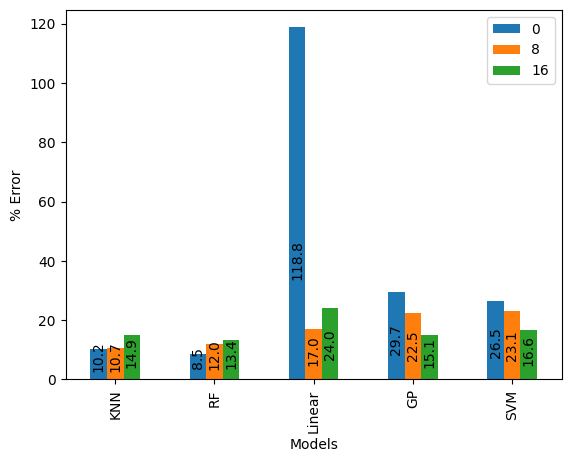

In [14]:
visualization_class_stratified(per_diff_class_stratified_test, path_name='')

In [15]:
feature_param = []

for feature in features_list:
    feature_param.append((X_train[feature].min(), X_train[feature].max()))

In [16]:
# Create a data Generator 
threshold_of_agreement = 2
def random_feature_generator(all_models, batch_size, feature_size, num_datasize=10000):
    for i in range(num_datasize//batch_size):
        batch_input      = np.random.randn(batch_size*2, feature_size)
        
        batch_output_knn = all_models[model_to_num['KNN']].predict(batch_input)[..., np.newaxis]
        batch_output_rf  = all_models[model_to_num['RF']].predict(batch_input)[..., np.newaxis]

        # Select only the if they both have output similar and take average of it
        batch_diff      = np.abs(batch_output_knn - batch_output_rf)              # Find the different in the output

        flag_to_reject  = (batch_diff < threshold_of_agreement).squeeze()         # reject the items tha at have difference in the threshold of less than 2
        batch_output    = np.mean([batch_output_knn, batch_output_rf], axis=0)    # Average the output labels
        
        yield  batch_input[flag_to_reject], batch_output[flag_to_reject]

In [17]:
# Check the percent error for each model combined
batch_size   = 64
input_size   = 6
num_datasize = 100000
X, y = next(random_feature_generator(all_models, batch_size, input_size, num_datasize))


for model_name in ['KNN', 'RF']:
    print(model_name, per_error(y.squeeze(), all_models[model_to_num[model_name]].predict(X).squeeze(), y_LOD))
X.shape, y.shape

KNN 12.960077282199443
RF 7.769985629377303


((55, 6), (55, 1))

In [ ]:
# Train the model
wandb.init(project="Epilepsy", name="Neural network ensemble learning")

iteration    = 100000
lr           = 1e-4
batch_size   = 64
num_hidden_layer = 8
num_datasize = 30000
input_size   = len(features_list)
reduce_lr_epoch = 5000
reduce_lr_rate  = 0.1

device = 'cuda' if torch.cuda.is_available() else 'cpu'

model          = VoltNeural(input_size, num_hidden_layer, 1, device)

# torch.save(model, 'initial.pth')
# load model structure to wandb
# wandb.watch(model, log="all")

# Define loss function
criteron  = nn.MSELoss()

# Define optimizer
optim     = torch.optim.Adam(model.parameters(),lr=lr)
num_step  = num_datasize // batch_size

scheduler = torch.optim.lr_scheduler.StepLR(optim, step_size=reduce_lr_epoch, gamma=reduce_lr_rate)

for epoch in range(iteration):
    model.train()
    data_generator = random_feature_generator(all_models, batch_size, input_size, num_datasize)

    for X, y in data_generator:
        X_ = torch.tensor(X, dtype=torch.float32).to(device)
        y_ = torch.tensor(y, dtype=torch.float32).to(device)

        
        # Train Deep Learning Model
        output = model(X_) 
        loss   = criteron(output, y_)

        optim.zero_grad()
        loss.backward()
        optim.step()


    # Reduce learning rate
    scheduler.step()
    
    if (epoch%20 == 0):
        # Log metrics to wandb
        wandb.log({
            "epoch": epoch,
            "loss": loss.item(),
            "learning_rate": scheduler.get_last_lr()[0],
        })
        model.eval()
        print(f"Epoch:{epoch} | Loss:{loss.item():.2f} | Learning_rate:{scheduler.get_last_lr()[0]}")

    # Save the model every 100 epochs
    if (epoch + 1) % 100 == 0:
        model_path = f"weights/nn_model_{epoch+1}.pth"
        os.makedirs(os.path.dirname(model_path), exist_ok=True)
        torch.save(model, model_name)
        wandb.save(model_path)
        print(f"Model Saved to {model_path}")

wandb: Currently logged in as: buddhacs (san1997). Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


Epoch:0 | Loss:103.89 | Learning_rate:0.0001
Epoch:20 | Loss:1.63 | Learning_rate:0.0001
Epoch:40 | Loss:0.67 | Learning_rate:0.0001
Epoch:60 | Loss:0.90 | Learning_rate:0.0001
Epoch:80 | Loss:0.41 | Learning_rate:0.0001
Model Saved to weights/nn_model_100.pth
Epoch:100 | Loss:0.75 | Learning_rate:0.0001
Epoch:120 | Loss:0.65 | Learning_rate:0.0001
Epoch:140 | Loss:0.50 | Learning_rate:0.0001
Epoch:160 | Loss:0.61 | Learning_rate:0.0001
Epoch:180 | Loss:0.77 | Learning_rate:0.0001
Model Saved to weights/nn_model_200.pth
Epoch:200 | Loss:0.34 | Learning_rate:0.0001
Epoch:220 | Loss:0.54 | Learning_rate:0.0001
Epoch:240 | Loss:0.50 | Learning_rate:0.0001
Epoch:260 | Loss:0.69 | Learning_rate:0.0001
Epoch:280 | Loss:0.42 | Learning_rate:0.0001
Model Saved to weights/nn_model_300.pth
Epoch:300 | Loss:0.55 | Learning_rate:0.0001
Epoch:320 | Loss:0.42 | Learning_rate:0.0001
Epoch:340 | Loss:0.35 | Learning_rate:0.0001
Epoch:360 | Loss:0.37 | Learning_rate:0.0001
Epoch:380 | Loss:0.37 | Learn

In [ ]:
torch.save(model, 'knn_trained_nn_model.pth')

In [ ]:
model = torch.load('knn_trained_nn_model.pth')

In [ ]:
# Train the model
iteration    = 100000 
lr           = 1e-5
batch_size   = 64
num_datasize = len(X_train)
num_hidden_layer = 4

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Define loss function
criteron  = nn.MSELoss()

# Define optimizer
optim     = torch.optim.Adam(model.parameters(),lr=lr)
num_step  = num_datasize // batch_size

for epoch in range(iteration):
    model.train()

    for i in range(num_step):
        start = i*batch_size
        end   = start + batch_size

        X_    = torch.tensor(X_train[features_list][start:end].to_numpy(), dtype=torch.float32).to(device)
        y_    = torch.tensor(y_train[start:end].to_numpy()[..., np.newaxis], dtype=torch.float32).to(device)

        # Train Deep Learning Model
        output = model(X_) 
        loss   = criteron(output, y_)

        optim.zero_grad()
        loss.backward()
        optim.step()

    if (epoch%1000 == 0):
        model.eval()
        y_test_pred = model(torch.tensor(X_test[features_list].to_numpy(), dtype=torch.float32).to(device))
        test_loss   = nn.MSELoss()(y_test_pred, torch.tensor(y_test.to_numpy()[..., np.newaxis]).to(device))
        print(f"Epoch:{epoch} | Loss:{loss.item():.2f} | Test Loss: {test_loss}")
        # model.train()

In [ ]:
y_test.shape

In [ ]:

model.eval()
y_nn_pred = model(torch.tensor(X_test[features_list].to_numpy(), dtype=torch.float32).to(device))
per_error(y_test.to_numpy().squeeze(), y_nn_pred.detach().cpu().numpy().squeeze(), y_LOD)

In [ ]:
per_error(y_test.to_numpy().squeeze(), knn_model.predict(X_test[features_list].to_numpy()).squeeze(), y_LOD)

In [ ]:
13.871490860262739  - 9.274798276655122